# Monobank Finance X-Ray: Machine Learning & Predictive Analytics

This notebook applies advanced Machine Learning algorithms and Time Series Analysis to our Monobank financial history to extract actionable business intelligence. The core objectives involve utilizing K-Means clustering to uncover hidden behavioral personas in daily expenses, deploying Time Series logic with Coefficient of Variation metrics to identify rigid lifestyle routines, leveraging an Isolation Forest model for anomaly detection and anti-fraud alerting, and concluding with a dynamic Burn Rate and Financial Runway projection powered by live API data.

In [65]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import datetime


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

sys.path.append(os.path.abspath('..'))
from src.database import engine

load_dotenv('../.env')

query = "SELECT * FROM transactions ORDER BY time"
df_raw = pd.read_sql(query, engine)

print(f"Loaded {len(df_raw)} TOTAL transactions from Database.")

df = df_raw[df_raw['amount'] < 0].copy()

df['amount'] = df['amount'].abs()

print(f"Filtered {len(df)} expense transactions for Machine Learning!")

Loaded 3857 TOTAL transactions from Database.
Filtered 2909 expense transactions for Machine Learning!


## 1. Feature Engineering & Preprocessing for K-Means

To uncover latent spending patterns, we prepare our dataset for the K-Means algorithm by extracting temporal context-specifically the hour of the day and the day of the week-from our transaction timestamps. Because K-Means relies on distance metrics to group similar data points, we consolidate these temporal features with the transaction amount and apply a Standard Scaler to normalize the dataset, ensuring that large monetary values do not disproportionately dominate the clustering process over the critical time-based variables.

In [66]:
df_ml = df[['time', 'amount', 'description', 'category']].copy()
df_ml['hour'] = df_ml['time'].dt.hour
df_ml['day_of_week'] = df_ml['time'].dt.dayofweek

features = df_ml[['amount', 'hour', 'day_of_week']]

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

## 1. Finding the Optimal K (Elbow Method)

Before interpreting the cluster profiles, we must determine the optimal number of groups (K) to avoid over-segmenting our dataset. By calculating the Within-Cluster Sum of Squares (WCSS) for a range of one to ten clusters, we can visually identify the inflection point of diminishing returns, ensuring our K-Means model perfectly balances mathematical inertia reduction with practical business interpretability.

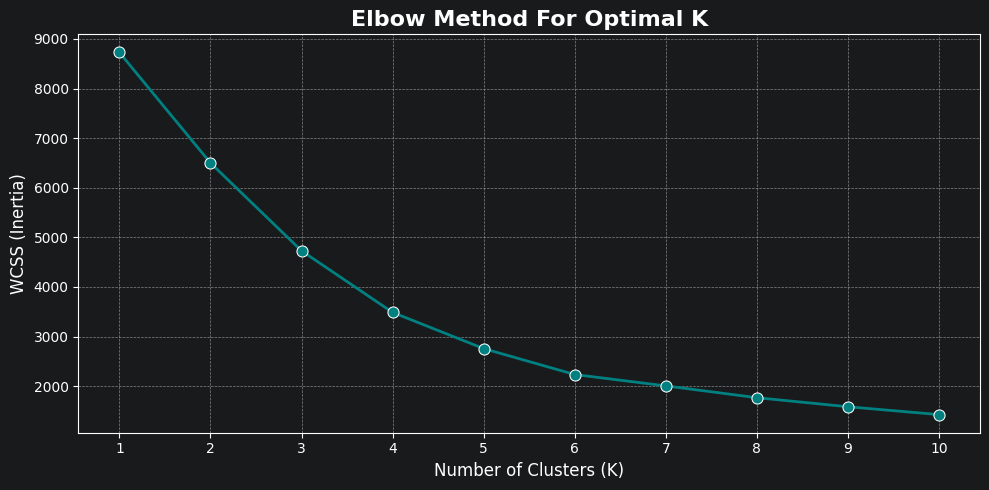

In [67]:
wcss = []
k_range = range(1, 11)

for i in k_range:
    kmeans_test = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans_test.fit(features_scaled)
    wcss.append(kmeans_test.inertia_)

plt.figure(figsize=(10, 5))
sns.lineplot(x=list(k_range), y=wcss, marker='o', color='teal', linewidth=2, markersize=8)
plt.title('Elbow Method For Optimal K', fontsize=16, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Inertia)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Elbow Method shown us that 4 clusters is optimal amount

In [68]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_ml['cluster'] = kmeans.fit_predict(features_scaled)

print("K-Means model successfully trained and assigned 4 clusters!")
display(df_ml[['time', 'amount', 'description', 'cluster']].head(10))

K-Means model successfully trained and assigned 4 clusters!


,time,amount,description,cluster
1,2021-10-25 14:21:37,18.40,АТБ №792,0
2,2021-10-25 17:07:58,14.49,Сільпо,0
4,2021-10-25 17:31:28,34.50,АТБ,0
5,2021-10-25 18:06:53,17.00,MagazinProdukti,0
7,2021-10-26 11:59:13,30.20,АТБ №792,0
9,2021-10-27 12:19:33,122.00,McDonald’s,0
10,2021-10-28 16:14:31,11.30,АТБ,0
11,2021-10-28 17:35:10,30.20,АТБ,0
12,2021-10-28 18:04:05,9.90,OPT 243 PAVIC,0
15,2021-11-05 18:31:08,402.00,Банкомат IVANA MAZEPY. 37,1


## 2. Cluster Profiling: Understanding the Patterns

To interpret what each mathematical cluster represents in reality, we profile these groups by calculating the average transaction amount, the typical time of day, the most frequent day of the week, and the dominant spending category. This multidimensional aggregation allows us to translate raw data points into distinct behavioral "personas" - such as weekday morning coffee routines or weekend bulk grocery shopping - providing actionable business context to our unsupervised machine learning model.

In [69]:
cluster_summary = df_ml.groupby('cluster').agg(
    Transaction_Count=('amount', 'count'),
    Average_Amount_UAH=('amount', 'mean'),
    Average_Hour=('hour', 'mean'),
    Most_Frequent_Day=('day_of_week', lambda x: x.mode()[0] if not x.mode().empty else None)
).round(2)

top_categories = df_ml.groupby('cluster')['category'].agg(lambda x: x.mode()[0])
cluster_summary['Top_Category'] = top_categories

print("Cluster Profiles:")
display(cluster_summary)

Cluster Profiles:


,Transaction_Count,Average_Amount_UAH,Average_Hour,Most_Frequent_Day,Top_Category
cluster,,,,,
0,1165,122.42,15.34,2,Markets / Specialty Foods
1,911,101.21,15.53,6,Markets / Specialty Foods
2,798,131.81,9.05,4,Markets / Specialty Foods
3,35,5291.11,14.11,2,Money Transfers


## 3. 3D Visualization of Financial Habits

To better understand the boundaries between our identified behaviors, we can visualize the K-Means clusters in a 3-dimensional space. By mapping our features to the X, Y, and Z axes, we can visually inspect how the algorithm separated the data points.

* **X-axis (Hour of Day):** Differentiates morning routines from evening activities.
* **Y-axis (Day of Week):** Separates weekday expenditures from weekend shopping.
* **Z-axis (Amount):** Isolates standard daily purchases from rare, high-value transfers.

This spatial representation provides a clear visual confirmation of the cluster profiles we defined above.

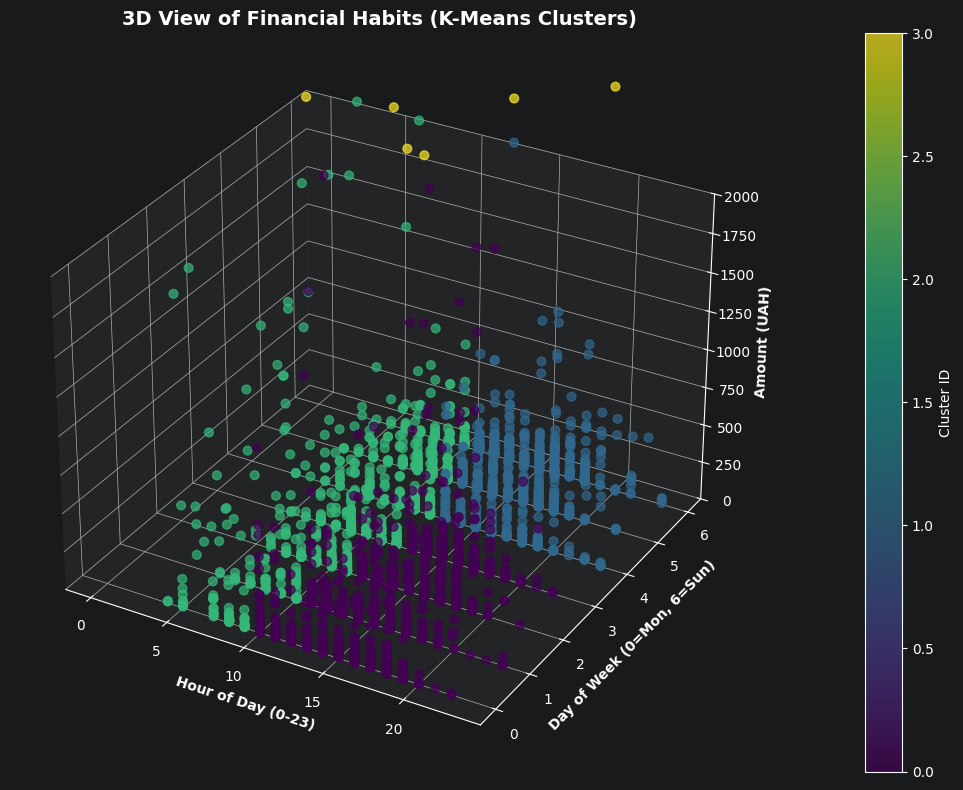

In [70]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df_ml['hour'],
    df_ml['day_of_week'],
    df_ml['amount'],
    c=df_ml['cluster'],
    cmap='viridis',
    s=40,
    alpha=0.7
)

ax.set_xlabel('Hour of Day (0-23)', fontweight='bold')
ax.set_ylabel('Day of Week (0=Mon, 6=Sun)', fontweight='bold')
ax.set_zlabel('Amount (UAH)', fontweight='bold')
ax.set_title('3D View of Financial Habits (K-Means Clusters)', fontsize=14, fontweight='bold')

ax.set_zlim(0, 2000)

cbar = plt.colorbar(scatter, pad=0.1)
cbar.set_label('Cluster ID')

plt.tight_layout()
plt.show()

## 4. Time Series Analysis: Behavioral Routine & Habit Detection

While standard recurring payments are common, identifying predictable behavioral routines provides deeper insight into daily lifestyle. To uncover these regular habits, this algorithm standardizes merchant names to resolve data entry inconsistencies and groups transactions to calculate the time gap in days between consecutive visits. We identify true "Consumer Hubs" by evaluating transaction volume alongside the stability of this cadence using Interval Volatility and the Coefficient of Variation (CV), allowing us to mathematically distinguish between rigid lifestyle routines and sporadic, chaotic spending.

In [71]:
df_ml['clean_description'] = df_ml['description'].str.strip().str.lower().str.capitalize()

merchant_counts = df_ml['clean_description'].value_counts()
frequent_merchants = merchant_counts[merchant_counts >= 5].index
frequent_tx = df_ml[df_ml['clean_description'].isin(frequent_merchants)].copy()

frequent_tx = frequent_tx.sort_values(by=['clean_description', 'time'])

frequent_tx['days_since_last'] = frequent_tx.groupby('clean_description')['time'].diff().dt.days

routine_stats = frequent_tx.groupby('clean_description').agg(
    Tx_Count=('amount', 'count'),
    Avg_Amount_UAH=('amount', 'mean'),
    Median_Interval_Days=('days_since_last', 'median'),
    Interval_Volatility=('days_since_last', 'std')
).dropna()

routine_stats['CV'] = routine_stats['Interval_Volatility'] / routine_stats['Median_Interval_Days'].replace(0, np.nan)

print("Consumer Hubs & Behavioral Routines Analysis:")
display(routine_stats.sort_values(by='Tx_Count', ascending=False).head(10).round(2))

Consumer Hubs & Behavioral Routines Analysis:


,Tx_Count,Avg_Amount_UAH,Median_Interval_Days,Interval_Volatility,CV
clean_description,,,,,
Атб,276,47.88,2.0,10.47,5.23
Київське метро,249,8.00,0.0,16.13,NaN
Маркетопт,219,73.18,1.0,18.75,18.75
Фора,204,99.48,1.0,10.20,10.20
Ipay.ua,199,10.12,0.0,16.18,NaN
Переказ на картку,94,294.12,0.0,9.18,NaN
Сільпо,77,83.52,5.0,41.66,8.33
Mcdonald’s,67,202.04,10.0,76.28,7.63
Кицюня❤️,64,238.03,6.0,10.00,1.67


## 5. Predictive Analytics: Financial Runway (Burn Rate)

In startups and personal finance, "Burn Rate" is the speed at which money is spent. To project our "Financial Runway" - a data-driven estimation of how many days our current capital will last before hitting zero - we implement a robust, offline-first architecture by extracting our absolute latest balance directly from the raw database snapshot as a single source of truth. By calculating our average daily spending strictly over the most recent 30 days and completely decoupling the model from external banking APIs, we ensure our predictive analytics remain entirely autonomous, perfectly synchronized with our transaction history, and completely immune to network or service outages.

Current Balance: 257.21 UAH
Analysis Window: 2026-05-08 to 2026-06-07

Total Spend in last 30 days: 16501.90 UAH
True Average Daily Burn Rate: 550.06 UAH / day
Financial Runway: 0 days
Projected Zero Balance Date: 2026-06-07


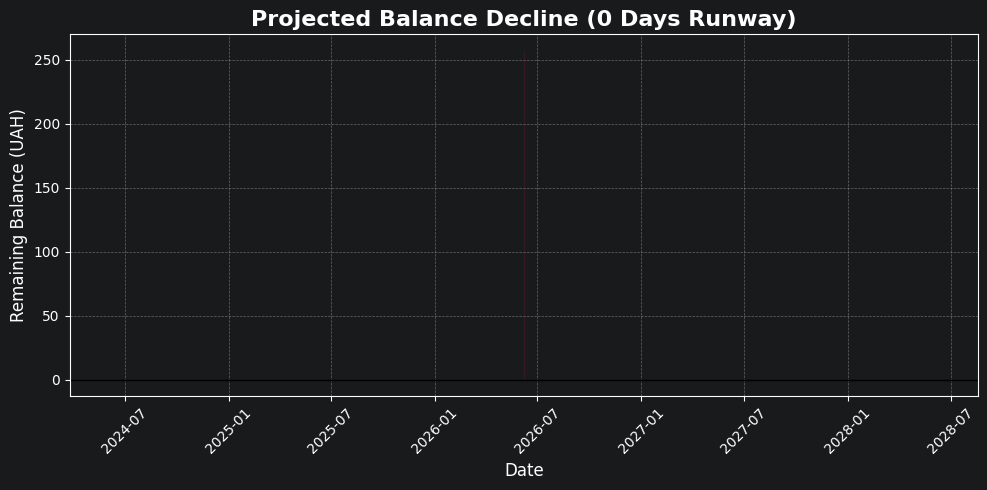

In [72]:
latest_idx = df_raw['time'].idxmax()
CURRENT_BALANCE = df_raw.loc[latest_idx, 'balance']

today_date = pd.Timestamp.now().normalize()
start_date = today_date - pd.Timedelta(days=30)

print(f"Current Balance: {CURRENT_BALANCE} UAH")
print(f"Analysis Window: {start_date.date()} to {today_date.date()}")

recent_df = df_ml[(df_ml['time'] >= start_date) & (df_ml['time'] < today_date + pd.Timedelta(days=1))]

total_spend_30_days = recent_df['amount'].sum()
avg_daily_burn = total_spend_30_days / 30.0

if avg_daily_burn > 0:
    runway_days = int(CURRENT_BALANCE / avg_daily_burn)

    zero_cash_date = today_date + pd.Timedelta(days=runway_days)

    print(f"\nTotal Spend in last 30 days: {total_spend_30_days:.2f} UAH")
    print(f"True Average Daily Burn Rate: {avg_daily_burn:.2f} UAH / day")
    print(f"Financial Runway: {runway_days} days")
    print(f"Projected Zero Balance Date: {zero_cash_date.date()}")

    future_dates = [today_date.date() + datetime.timedelta(days=i) for i in range(runway_days + 1)]
    projected_balances = [CURRENT_BALANCE - (avg_daily_burn * i) for i in range(runway_days + 1)]

    plt.figure(figsize=(10, 5))
    plt.plot(future_dates, projected_balances, color='crimson', linewidth=2, linestyle='-')
    plt.fill_between(future_dates, projected_balances, 0, color='crimson', alpha=0.15)

    plt.title(f"Projected Balance Decline ({runway_days} Days Runway)", fontsize=16, fontweight='bold')
    plt.xlabel("Date", fontsize=12)
    plt.ylabel("Remaining Balance (UAH)", fontsize=12)
    plt.axhline(0, color='black', linewidth=1)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough recent expenses to calculate a valid burn rate (Burn rate is 0).")

## 5. Anomaly Detection: Anti-Fraud & Irregular Spending Analysis

While K-Means groups our common behaviors and Time Series analysis detects stable habits, how do we spot the outliers? In real-world fintech, identifying anomalous transactions is the absolute foundation of **Anti-Fraud systems** and impulsive spending alerts.

Here, we implement an **Isolation Forest** (an unsupervised machine learning algorithm) to detect financial anomalies. Rather than profiling what is "normal", it mathematically isolates data points that are rare and fundamentally different from the rest of the dataset.

To make the model context-aware, we evaluate transactions across multiple dimensions:
* **Amount:** Is the transaction unusually large (or small) for this specific merchant?
* **Hour of Day:** Was the purchase made during typical hours or at 3:00 AM?
* **Day of Week:** Does this spending pattern fit the usual weekday/weekend dynamic?

We set the `contamination` parameter to `0.03`, explicitly instructing the algorithm to flag the top 3% most unusual transactions in the entire history.

In [73]:
df_ml['hour'] = df_ml['time'].dt.hour
df_ml['day_of_week'] = df_ml['time'].dt.dayofweek

if 'clean_description' not in df_ml.columns:
    df_ml['clean_description'] = df_ml['description'].str.strip().str.lower().str.capitalize()

features_for_anomaly = ['amount', 'hour', 'day_of_week']
X_anomaly = df_ml[features_for_anomaly].dropna()

iso_forest = IsolationForest(n_estimators=100, contamination=0.03, random_state=42)
iso_forest.fit(X_anomaly)

df_ml['is_anomaly'] = iso_forest.predict(X_anomaly)

anomalies_df = df_ml[df_ml['is_anomaly'] == -1].copy()
anomalies_df = anomalies_df.sort_values(by='amount', ascending=False)

# Виводимо результати
print("Top 10 Financial Anomalies (Anti-Fraud / Irregular Spends):")
display(anomalies_df[['time', 'clean_description', 'amount', 'category', 'hour', 'day_of_week']].head(10))

Top 10 Financial Anomalies (Anti-Fraud / Irregular Spends):


,time,clean_description,amount,category,hour,day_of_week
2146,2025-03-25 15:05:07,Wizz air,21445.24,Airlines,15,1
2174,2025-03-31 15:59:52,Booking.com,11760.96,Hotels / Lodging,15,0
2138,2025-03-23 17:34:32,Поповнення «заощадження»,10000.00,Money Transfers,17,6
3365,2026-02-01 08:59:34,Переказ на картку,7400.00,Money Transfers,8,6
3166,2025-12-10 12:16:06,Поповнення «мої накопичення»,7000.00,Money Transfers,12,2
1831,2024-12-05 10:20:29,Booking.com,6846.83,Travel Agencies / Booking,10,3
3179,2025-12-10 19:33:04,Booking.com,6455.94,Hotels / Lodging,19,2
1644,2024-10-23 14:54:30,Adidas,6299.00,Sportswear / Apparel,14,2
2175,2025-03-31 16:30:25,Flixbus,6087.32,Bus Lines / Coaches,16,0
3123,2025-12-02 19:07:53,Answear,5066.58,Family Clothing,19,1
